# 1D H Chain

## Imports

In [1]:
from ase import Atoms
from ase.calculators.openmx import OpenMX

from kodiak_openmx import (
    OpenMXScfout,
    run_openmx,
    read_openmx_band,
    get_job_status
)

import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
prefix = "H_chain"

workdir = os.path.join(
    "..", "..", "calcs", "examples", "H_chain_1D"
)

Path(workdir).mkdir(parents=True, exist_ok=True)

print("Workdir:", workdir)

Workdir: ../../calcs/examples/H_chain_1D


## 1D Crystal System

In [3]:
atoms = Atoms(
    "H",
    positions=[(0.0, 0.0, 0.0)],
    cell=(3.0, 15.0, 15.0),
    pbc=[True, True, True]
)


In [4]:
nk = 101

calc = OpenMX(
    data_path='/usr/local/apps/openmx/3.9/DFT_DATA19',
    directory=workdir,
    system_currentdirectory='./',
    command=f'command="openmx {prefix}.dat > {prefix}.out",',
    label=prefix,

    definition_of_atomic_species=[['H','H5.0-s2p1','H_PBE19']],

    scf_kgrid=(24, 1, 1),
    scf_spinpolarization='on',
    scf_xctype='GGA-PBE',

    scf_eigenvaluesolver='dc',
    scf_maxiter=100,
    scf_energycutoff=150,

    hs_fileout=True,

    band_dispersion=True,
    band_nkpath=1,
    band_kpath=[
        [
            nk,
            -0.5, 0.0, 0.0,
            0.5, 0.0, 0.0,
            "X", "X"
        ]
    ],
)

atoms.calc = calc
calc.write_input(atoms)

In [5]:
run_openmx(prefix, workdir, verbose=True)

status_file = os.path.join(workdir, "scf_status.txt")
output_file = os.path.join(workdir, "outputFile.std")

job_status = get_job_status(status_file, output_file)

print("Job status:", job_status)

assert job_status == "done", "Job not finished."

Job ID: 3998195
Status file detected. Calculation skipped.
Job status: done


## Postprocessing

In [6]:
scf = OpenMXScfout(
    os.path.join(workdir, f"{prefix}.scfout")
)

print("nbasis:", scf.nbasis)

nbasis: 5


## Validation

### Is the Hamiltonian Hermitian?

In [7]:
H = scf.H_R.toarray()

max_error = np.max(np.abs(H - H.conj().T))

print("Hermiticity error:", max_error)

Hermiticity error: 9.163959521774068e-11


### Band Structure

In [8]:
from scipy.linalg import eigh

a = np.linalg.norm(scf.tv[0])
b = 2 * np.pi / a

nk_dense = 200

kvals = np.linspace(-0.5 * b, 0.5 * b, nk_dense)

bands = []

for kx in kvals:
    kvec = np.array([kx, 0, 0])

    Hk = scf.Hk(kvec)
    Sk = scf.Sk(kvec)

    if Sk is None:
        print(f'Sk = {Sk}')
        eigvals, _ = np.linalg.eigh(Hk)
    else:
        eigvals, eigvecs = eigh(Hk, Sk)

    bands.append(np.sort(eigvals.real))

bands = np.array(bands)

In [1]:
! pwd

/ion/home/blaire/Research/kodiak-openmx/notebooks/examples


In [3]:
! ls -lt ../../calcs/examples/H_chain_1D

total 57351
-rw------- 1 blaire blaire     133 May 23 22:21 scf_status.txt
-rw------- 1 blaire blaire   15483 May 23 22:21 outputFile.std
-rw------- 1 blaire blaire    9614 May 23 22:21 H_chain.out
-rw------- 1 blaire blaire   33596 May 23 22:21 H_chain.scfout
-rw------- 1 blaire blaire     805 May 23 22:21 H_chain.bulk.xyz
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.vhart.cube
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.v1.cube
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.v0.cube
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.sden.cube
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.den1.cube
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.den0.cube
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.tden.cube
-rw------- 1 blaire blaire 3469434 May 23 22:21 H_chain.dden.cube
-rw------- 1 blaire blaire      97 May 23 22:21 H_chain.xyz
-rw------- 1 blaire blaire    1138 May 23 22:21 H_chain.dat#
-rw------- 1 blaire blaire  

## Validation

We check that the `Sk` matrix is not ill-conditioned. We ant to see a non-huge value for the condition number of `Sk`.

In [11]:
huge = 1e8
assert np.linalg.cond(Sk) <= huge, 'Sk is ill-conditioned.' 

print(np.linalg.cond(Sk))

1.7568723795096377


We want the eigenvalues to be real, or to have negligible imaginary parts:

In [14]:
import math

real_eigvals = math.isclose(np.max(np.abs(eigvals.imag)), 0)
assert real_eigvals, "Eigenvalues are not all real."

### Load the OpenMX Reference Data

In [15]:
bands_data = os.path.join(workdir, f"{prefix}.Band")

k_openmx, bands_openmx, Ef = read_openmx_band(
    bands_data,
    scf.reciprocal_vectors()
)

print("Fermi level:", Ef)

Fermi level: -6.077774377291144


Align energies:

In [16]:
bands = bands * 27.2114 - Ef

Plot the calculated band structure and the reference OpenMX band structure:

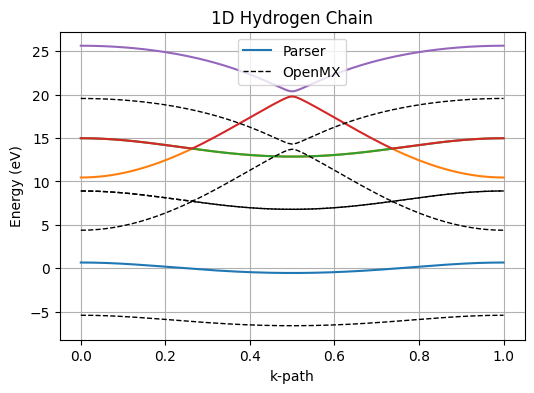

In [17]:
x_parser = np.linspace(0, 1, len(kvals))
x_openmx = k_openmx / np.max(k_openmx)

plt.figure(figsize=(6,4))

for n in range(bands.shape[1]):
    plt.plot(x_parser, bands[:, n],
             label="Parser" if n == 0 else None)

for n in range(bands_openmx.shape[1]):
    plt.plot(x_openmx, bands_openmx[:, n],
             "k--", linewidth=1,
             label="OpenMX" if n == 0 else None)

plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.title("1D Hydrogen Chain")

plt.grid(True)
plt.legend()
plt.show()

We can see that there's an offsett of about 6 eV, so we can adjust this plot for a better visual comparison:

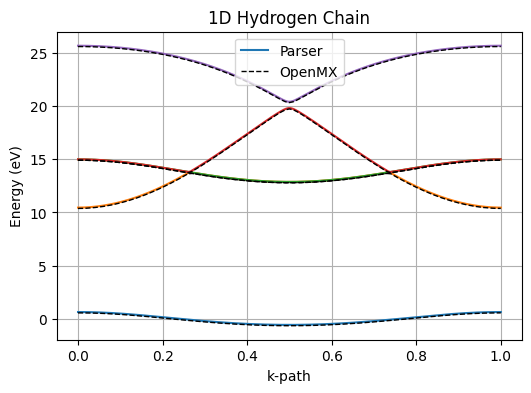

In [18]:
x_parser = np.linspace(0, 1, len(kvals))
x_openmx = k_openmx / np.max(k_openmx)

offsett = 6 # eV

plt.figure(figsize=(6,4))

for n in range(bands.shape[1]):
    plt.plot(x_parser, bands[:, n],
             label="Parser" if n == 0 else None)

for n in range(bands_openmx.shape[1]):
    plt.plot(x_openmx, bands_openmx[:, n] + offsett,
             "k--", linewidth=1,
             label="OpenMX" if n == 0 else None)

plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.title("1D Hydrogen Chain")

plt.grid(True)
plt.legend()
plt.show()

Now we see that we have very nice agreement between the OpenMX result and our result determined from the extracted real-space Hamiltonian and overlap matrices.